In [1]:
import sys
from pathlib import Path

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import os
os.chdir(project_root)

In [2]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.data.pipeline import extract_dataset, get_datasets
from src.data.dataset import time_series_split, create_sequences
from src.data.news_sentiment import load_daily_sentiment, merge_sentiment_features
from src.models.transformer_model import StockTransformer
from src.simulation.engine import BacktestEngine
from src.simulation.metrics import compute_metrics
from src.utils.config import load_config, split_per_symbol
from src.utils import config as _cfg

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

config = load_config()
print("Config loaded:", config.paths.checkpoint_file)

Config loaded: best_model_base.pt


## 1. Load both checkpoints

Each checkpoint stores its own input feature count and validation loss. We rebuild the matching `StockTransformer` instance from the state dict shapes (more reliable than relying on the config alone).

In [3]:
def load_checkpoint_model(checkpoint_name: str):
    path = _cfg.PROJECT_ROOT / config.paths.models_dir / checkpoint_name
    if not path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {path}")

    ckpt = torch.load(path, map_location="cpu")
    sd = ckpt["model_state_dict"]

    input_dim = sd["input_projection.weight"].shape[1]
    d_model = sd["input_projection.weight"].shape[0]
    n_layers = len([k for k in sd if "encoder.layers" in k and "self_attention.w_q.weight" in k])
    d_ff = sd["encoder.layers.0.feed_forward.linear1.weight"].shape[0]

    model = StockTransformer(
        input_dim=input_dim,
        d_model=d_model,
        n_heads=config.model.n_heads,
        n_layers=n_layers,
        d_ff=d_ff,
        dropout=config.model.dropout,
        activation=config.model.activation,
        prediction_horizon=config.data.prediction_horizon,
    )
    model.load_state_dict(sd)
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())

    return {
        "model": model,
        "path": path,
        "input_dim": input_dim,
        "val_loss": ckpt.get("score"),
        "epoch": (ckpt.get("epoch", 0) or 0) + 1,
        "n_params": n_params,
        "mtime": time.ctime(path.stat().st_mtime),
    }

base = load_checkpoint_model("best_model_base.pt")
news = load_checkpoint_model("best_model_news.pt")

header_df = pd.DataFrame({
    "Model":             ["Base (technical only)", "News-enhanced (FinBERT)"],
    "Input features":    [base["input_dim"], news["input_dim"]],
    "Trainable params":  [f"{base['n_params']:,}", f"{news['n_params']:,}"],
    "Best epoch":        [base["epoch"], news["epoch"]],
    "Val loss":          [f"{base['val_loss']:.6f}", f"{news['val_loss']:.6f}"],
    "Modified":          [base["mtime"], news["mtime"]],
})
header_df

,Model,Input features,Trainable params,Best epoch,Val loss,Modified
0,Base (technical only),34,"4,747,777",18,0.000110,Thu May 28 14:09:11 2026
1,News-enhanced (FinBERT),40,"4,749,313",12,0.000110,Sat May 30 18:25:51 2026


## 2. Prepare test data for both models

Same chronological per-symbol split, but two different feature sets:

- **Base features:** technical indicators + lagged returns + temporal features.
- **News features:** all of the above + `news_compound`, `news_pos`, `news_neg`, `news_neu`, `news_count`, `news_has`.

We mutate the YAML config in-memory to toggle `use_news`, so both feature sets come from the exact same pipeline.

In [4]:
def get_test_panel(use_news: bool):
    cfg = load_config()
    cfg.data.use_news = use_news

    df, feature_columns = extract_dataset(config=cfg)
    _, _, test_df = time_series_split(
        df,
        train_split=cfg.data.train_split,
        val_split=cfg.data.val_split,
        test_split=cfg.data.test_split,
        per_symbol=split_per_symbol(cfg),
    )
    test_df = test_df.sort_values(["symbol", "date"]).reset_index(drop=True)
    return test_df, feature_columns

base_test_df,  base_features  = get_test_panel(use_news=False)
news_test_df,  news_features  = get_test_panel(use_news=True)

print(f"Base test rows : {len(base_test_df):,}  ({len(base_features)} features)")
print(f"News test rows : {len(news_test_df):,}  ({len(news_features)} features)")
print(f"Tickers (base) : {sorted(base_test_df['symbol'].unique())}")
print(f"Tickers (news) : {sorted(news_test_df['symbol'].unique())}")

Base test rows : 2,574  (34 features)
News test rows : 2,574  (40 features)
Tickers (base) : ['AAPL', 'AMZN', 'BAC', 'COST', 'CVX', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MA', 'MSFT', 'NFLX']
Tickers (news) : ['AAPL', 'AMZN', 'BAC', 'COST', 'CVX', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MA', 'MSFT', 'NFLX']


## 3. Inference + backtest helper

One function that, given a trained model and its test panel, returns:

- The aligned `predicted_returns`, `actual_returns`, `prices`, `dates`.
- The full `BacktestResult` from running `engine.run_smart_long_only` on those predictions.
- A flat dict of accuracy + trading metrics.

The trading engine and parameters are identical for both models — only the predictions change.

In [5]:
import yaml

config_path = _cfg.PROJECT_ROOT / "configs" / "default_config.yaml"
with config_path.open("r", encoding="utf-8") as f:
    raw_cfg = yaml.safe_load(f)
sim = raw_cfg.get("simulation", {})

initial_capital       = float(sim.get("initial_capital", 100_000))
position_size_pct     = float(sim.get("position_size_pct", 0.3))
commission_pct        = float(sim.get("commission_pct", 0.1))
risk_free_rate_annual = float(sim.get("risk_free_rate_annual", 0.03))

MIN_TRADING_DAYS = 80
ctx              = config.data.context_length
pred_horizon     = config.data.prediction_horizon
price_col        = config.data.price_column
target_col       = config.data.target_column

engine = BacktestEngine(
    initial_capital=initial_capital,
    position_size_pct=position_size_pct,
    commission_pct=commission_pct,
)

def run_one_ticker(model_obj, ticker_df, feature_columns):
    ticker_df = ticker_df.sort_values("date").reset_index(drop=True)
    if len(ticker_df) < ctx + pred_horizon + MIN_TRADING_DAYS:
        return None

    stacked = np.column_stack([
        ticker_df[feature_columns].values,
        ticker_df[target_col].values.reshape(-1, 1),
    ])
    seq_X, seq_y = create_sequences(stacked, ctx, pred_horizon)
    if len(seq_X) == 0:
        return None

    X = seq_X[:, :, :-1]
    actual_returns = (
        seq_y[:, :, -1].reshape(len(seq_X), -1)[:, -1]
        if pred_horizon > 1 else seq_y[:, -1, -1]
    )
    prices = ticker_df[price_col].values[ctx : ctx + len(seq_X)]
    dates  = ticker_df["date"].values[ctx : ctx + len(seq_X)]

    preds = []
    with torch.no_grad():
        for start in range(0, len(X), 64):
            batch = torch.FloatTensor(X[start : start + 64])
            preds.append(model_obj(batch).cpu())
    predicted_returns = torch.cat(preds).numpy().reshape(-1)

    result = engine.run_smart_long_only(
        prices=prices,
        predicted_returns=predicted_returns,
        dates=dates,
    )
    metrics = compute_metrics(
        result=result,
        initial_capital=initial_capital,
        risk_free_rate_annual=risk_free_rate_annual,
        prices=prices,
    )

    # accuracy metrics
    rmse = float(np.sqrt(np.mean((predicted_returns - actual_returns) ** 2)))
    mae  = float(np.mean(np.abs(predicted_returns - actual_returns)))
    correct_sign = np.sum(np.sign(predicted_returns) == np.sign(actual_returns))
    dir_acc = float(100 * correct_sign / len(actual_returns))

    return {
        "dates": dates,
        "prices": prices,
        "actual": actual_returns,
        "predicted": predicted_returns,
        "result": result,
        "metrics": {
            "rmse": rmse,
            "mae": mae,
            "directional_acc_pct": dir_acc,
            "total_return_pct":    metrics.total_return_pct,
            "sharpe":              metrics.sharpe_ratio_annual,
            "max_drawdown_pct":    metrics.max_drawdown_pct,
            "buy_hold_pct":        metrics.buy_and_hold_return_pct,
            "excess_vs_bh_pct":    metrics.excess_return_vs_bh_pct,
            "num_trades":          metrics.num_trades,
            "days":                len(prices),
        },
    }

def run_all_tickers(model_obj, test_df, feature_columns):
    out = {}
    for ticker, group in test_df.groupby("symbol"):
        r = run_one_ticker(model_obj, group, feature_columns)
        if r is not None:
            out[ticker] = r
    return out

print("Running base model on test set...")
base_results = run_all_tickers(base["model"], base_test_df, base_features)
print(f"  done — {len(base_results)} tickers")

print("Running news model on test set...")
news_results = run_all_tickers(news["model"], news_test_df, news_features)
print(f"  done — {len(news_results)} tickers")

Running base model on test set...


  done — 12 tickers
Running news model on test set...


  done — 12 tickers


## 4. Per-ticker summary table

One row per ticker, side-by-side comparison of every metric. The `Δ` columns show **news minus base** — positive means news helps.

In [6]:
common_tickers = sorted(set(base_results) & set(news_results))

def summary_row(t):
    b = base_results[t]["metrics"]
    n = news_results[t]["metrics"]
    return {
        "ticker": t,
        "days": b["days"],
        "buy_hold_pct": round(b["buy_hold_pct"], 2),
        "base_return_pct":  round(b["total_return_pct"], 2),
        "news_return_pct":  round(n["total_return_pct"], 2),
        "Δ_return":         round(n["total_return_pct"] - b["total_return_pct"], 2),
        "base_dir_acc":     round(b["directional_acc_pct"], 1),
        "news_dir_acc":     round(n["directional_acc_pct"], 1),
        "Δ_dir_acc":        round(n["directional_acc_pct"] - b["directional_acc_pct"], 1),
        "base_sharpe":      round(b["sharpe"], 2),
        "news_sharpe":      round(n["sharpe"], 2),
        "base_mdd":         round(b["max_drawdown_pct"], 2),
        "news_mdd":         round(n["max_drawdown_pct"], 2),
        "base_trades":      b["num_trades"],
        "news_trades":      n["num_trades"],
    }

summary_df = pd.DataFrame([summary_row(t) for t in common_tickers])
summary_df = summary_df.sort_values("Δ_return", ascending=False).reset_index(drop=True)

def colour(v):
    if pd.isna(v):
        return ""
    return "color: #16a34a" if v > 0 else ("color: #dc2626" if v < 0 else "color: #6b7280")

styled = (
    summary_df.style
    .applymap(colour, subset=["Δ_return", "Δ_dir_acc"])
    .format({
        "buy_hold_pct": "{:+.2f}%",
        "base_return_pct": "{:+.2f}%",
        "news_return_pct": "{:+.2f}%",
        "Δ_return": "{:+.2f}%",
        "base_dir_acc": "{:.1f}%",
        "news_dir_acc": "{:.1f}%",
        "Δ_dir_acc": "{:+.1f}%",
        "base_mdd": "{:.2f}%",
        "news_mdd": "{:.2f}%",
    })
)
styled

,ticker,days,buy_hold_pct,base_return_pct,news_return_pct,Δ_return,base_dir_acc,news_dir_acc,Δ_dir_acc,base_sharpe,news_sharpe,base_mdd,news_mdd,base_trades,news_trades
0,AAPL,155,+44.29%,+13.56%,+15.37%,+1.82%,55.5%,55.5%,+0.0%,2.280000,2.310000,3.08%,6.12%,12,17
1,JNJ,158,-0.08%,-0.77%,-0.03%,+0.75%,48.7%,48.7%,+0.0%,-0.960000,-0.730000,3.47%,2.69%,8,7
2,AMZN,141,+13.39%,+1.93%,+1.93%,+0.00%,41.1%,41.1%,+0.0%,0.210000,0.210000,1.34%,1.34%,2,2
3,MSFT,158,+12.71%,+4.22%,+3.89%,-0.33%,55.7%,55.7%,+0.0%,0.540000,0.470000,2.55%,2.74%,12,11
4,JPM,158,-29.23%,+1.98%,+0.90%,-1.08%,48.1%,48.1%,+0.0%,0.070000,-0.130000,4.72%,4.72%,19,17
5,KO,158,-16.27%,+1.12%,-0.05%,-1.17%,47.5%,47.5%,+0.0%,-0.150000,-0.470000,4.32%,4.48%,13,11
6,BAC,136,+15.90%,+0.09%,-1.16%,-1.25%,53.7%,53.7%,+0.0%,-0.210000,-0.440000,5.16%,4.71%,23,21
7,CVX,158,-32.76%,-6.21%,-7.79%,-1.58%,48.7%,48.7%,+0.0%,-1.350000,-1.630000,10.40%,11.91%,17,19
8,COST,158,+11.12%,+4.09%,+2.34%,-1.75%,51.3%,51.3%,+0.0%,0.730000,0.200000,3.36%,3.30%,9,8
9,GOOGL,158,-3.47%,+8.07%,+6.03%,-2.04%,54.4%,54.4%,+0.0%,1.370000,0.910000,2.21%,4.33%,10,13


## 5. Aggregate comparison

Two-number summary across all tickers — easy headline for the defense slide.

In [7]:
def aggregate(results):
    rmses   = [r["metrics"]["rmse"]              for r in results.values()]
    maes    = [r["metrics"]["mae"]               for r in results.values()]
    daccs   = [r["metrics"]["directional_acc_pct"] for r in results.values()]
    rets    = [r["metrics"]["total_return_pct"]  for r in results.values()]
    bhs     = [r["metrics"]["buy_hold_pct"]      for r in results.values()]
    excess  = [r["metrics"]["excess_vs_bh_pct"]  for r in results.values()]
    sharpes = [r["metrics"]["sharpe"]            for r in results.values()]
    mdds    = [r["metrics"]["max_drawdown_pct"]  for r in results.values()]
    trades  = [r["metrics"]["num_trades"]        for r in results.values()]
    return {
        "mean_rmse": np.mean(rmses),
        "mean_mae":  np.mean(maes),
        "mean_dir_acc": np.mean(daccs),
        "mean_return": np.mean(rets),
        "mean_buy_hold": np.mean(bhs),
        "mean_excess":  np.mean(excess),
        "median_excess": np.median(excess),
        "mean_sharpe": np.mean(sharpes),
        "mean_mdd": np.mean(mdds),
        "mean_trades": np.mean(trades),
        "beats_bh": sum(1 for e in excess if e > 0),
        "n": len(excess),
    }

agg_base = aggregate({t: base_results[t] for t in common_tickers})
agg_news = aggregate({t: news_results[t] for t in common_tickers})

agg_df = pd.DataFrame({
    "Metric": [
        "Mean RMSE (lower better)",
        "Mean MAE (lower better)",
        "Mean directional accuracy %",
        "Mean strategy return %",
        "Mean buy & hold return %",
        "Mean excess vs B&H %",
        "Median excess vs B&H %",
        "Mean Sharpe (annualised)",
        "Mean max drawdown %",
        "Mean trades per ticker",
        "Tickers beating B&H",
    ],
    "Base": [
        f"{agg_base['mean_rmse']:.5f}",
        f"{agg_base['mean_mae']:.5f}",
        f"{agg_base['mean_dir_acc']:.2f}%",
        f"{agg_base['mean_return']:+.2f}%",
        f"{agg_base['mean_buy_hold']:+.2f}%",
        f"{agg_base['mean_excess']:+.2f}%",
        f"{agg_base['median_excess']:+.2f}%",
        f"{agg_base['mean_sharpe']:+.3f}",
        f"{agg_base['mean_mdd']:.2f}%",
        f"{agg_base['mean_trades']:.1f}",
        f"{agg_base['beats_bh']} / {agg_base['n']}",
    ],
    "News": [
        f"{agg_news['mean_rmse']:.5f}",
        f"{agg_news['mean_mae']:.5f}",
        f"{agg_news['mean_dir_acc']:.2f}%",
        f"{agg_news['mean_return']:+.2f}%",
        f"{agg_news['mean_buy_hold']:+.2f}%",
        f"{agg_news['mean_excess']:+.2f}%",
        f"{agg_news['median_excess']:+.2f}%",
        f"{agg_news['mean_sharpe']:+.3f}",
        f"{agg_news['mean_mdd']:.2f}%",
        f"{agg_news['mean_trades']:.1f}",
        f"{agg_news['beats_bh']} / {agg_news['n']}",
    ],
})
agg_df

,Metric,Base,News
0,Mean RMSE (lower better),0.03211,0.03101
1,Mean MAE (lower better),0.02261,0.02130
2,Mean directional accuracy %,50.60%,50.60%
3,Mean strategy return %,+4.33%,+3.12%
4,Mean buy & hold return %,+3.69%,+3.69%
5,Mean excess vs B&H %,+0.65%,-0.57%
6,Median excess vs B&H %,-3.86%,-4.37%
7,Mean Sharpe (annualised),+0.517,+0.261
8,Mean max drawdown %,3.91%,4.39%
9,Mean trades per ticker,12.4,12.2


## 6. Visualisations

### 6.1 Accuracy metrics side by side

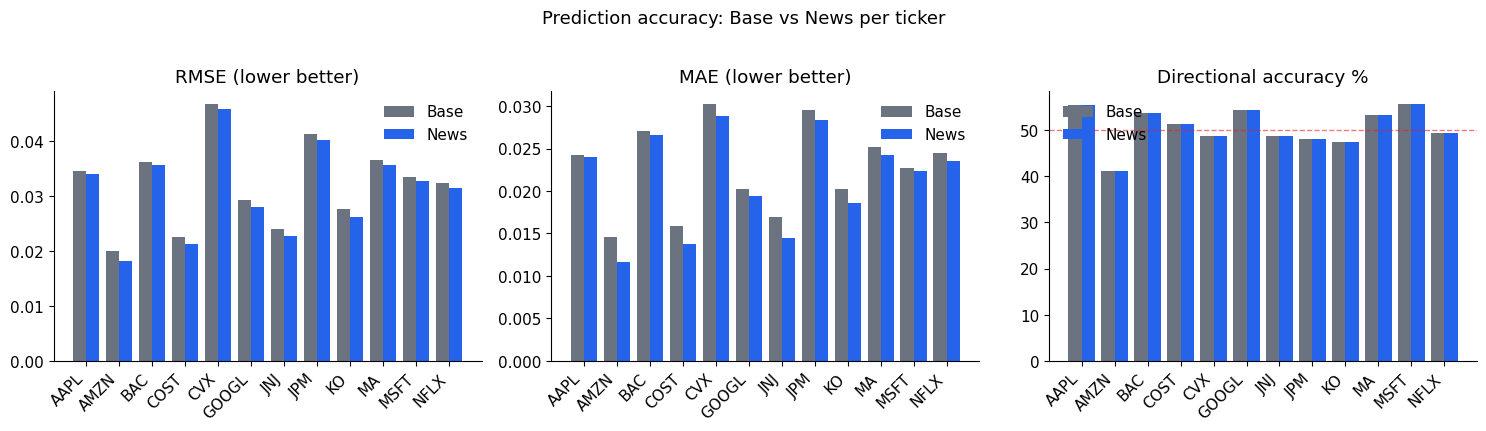

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
metrics_to_plot = [
    ("rmse",                "RMSE (lower better)",          axes[0]),
    ("mae",                 "MAE (lower better)",           axes[1]),
    ("directional_acc_pct", "Directional accuracy %",       axes[2]),
]
x = np.arange(len(common_tickers))
width = 0.4
for key, label, ax in metrics_to_plot:
    b_vals = [base_results[t]["metrics"][key] for t in common_tickers]
    n_vals = [news_results[t]["metrics"][key] for t in common_tickers]
    ax.bar(x - width/2, b_vals, width, label="Base",  color="#6b7280")
    ax.bar(x + width/2, n_vals, width, label="News",  color="#2563eb")
    ax.set_xticks(x)
    ax.set_xticklabels(common_tickers, rotation=45, ha="right")
    ax.set_title(label)
    ax.legend(frameon=False)
    if key == "directional_acc_pct":
        ax.axhline(50, color="#dc2626", linestyle="--", linewidth=1, alpha=0.6, label="random (50%)")
fig.suptitle("Prediction accuracy: Base vs News per ticker", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

### 6.2 Strategy return vs Buy & Hold per ticker

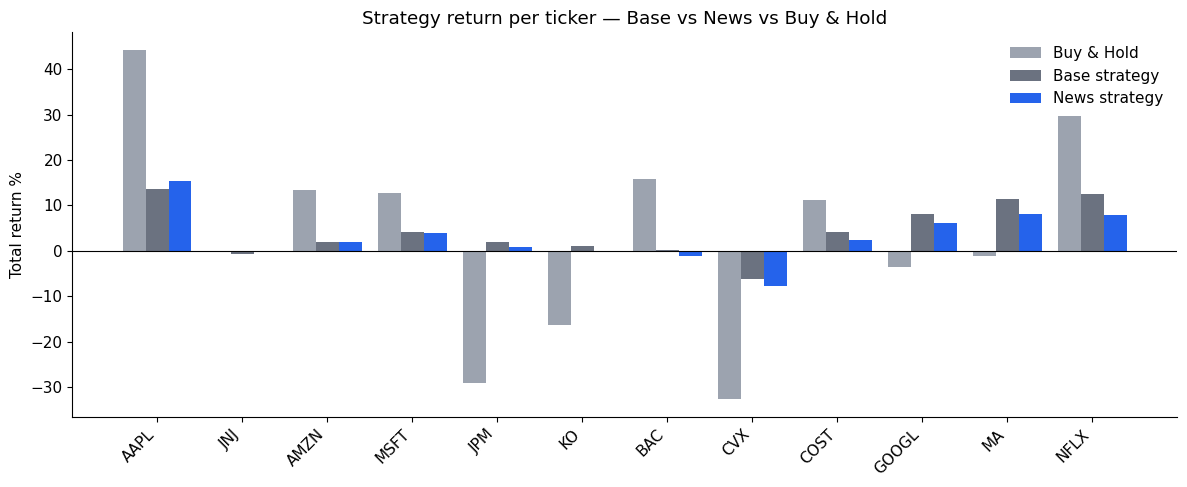

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
tickers_sorted = list(summary_df["ticker"])
x = np.arange(len(tickers_sorted))
width = 0.27

bh   = [base_results[t]["metrics"]["buy_hold_pct"]     for t in tickers_sorted]
rb   = [base_results[t]["metrics"]["total_return_pct"] for t in tickers_sorted]
rn   = [news_results[t]["metrics"]["total_return_pct"] for t in tickers_sorted]

ax.bar(x - width, bh, width, color="#9ca3af", label="Buy & Hold")
ax.bar(x,         rb, width, color="#6b7280", label="Base strategy")
ax.bar(x + width, rn, width, color="#2563eb", label="News strategy")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tickers_sorted, rotation=45, ha="right")
ax.set_ylabel("Total return %")
ax.set_title("Strategy return per ticker — Base vs News vs Buy & Hold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### 6.3 Equity curves — top 4 tickers where news helps the most

Picked automatically from the per-ticker `Δ_return` (positive = news > base).

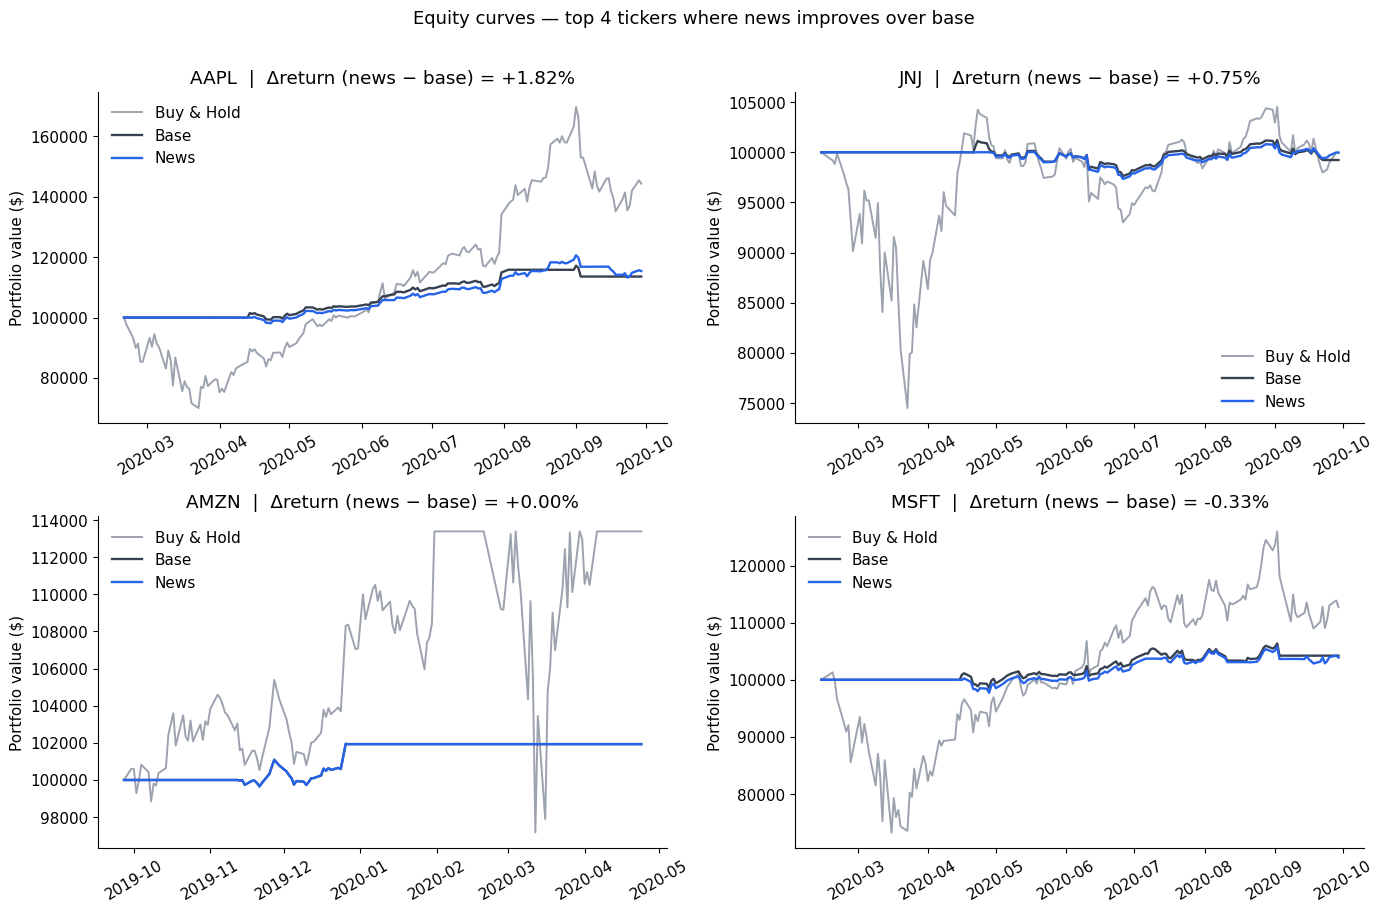

In [10]:
top_tickers = summary_df.head(4)["ticker"].tolist()
if len(top_tickers) < 4:
    top_tickers = common_tickers[:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, t in zip(axes.ravel(), top_tickers):
    br = base_results[t]
    nr = news_results[t]
    dates = pd.to_datetime(br["dates"])

    bh_curve = initial_capital * (br["prices"] / br["prices"][0])
    ax.plot(dates, bh_curve,                  color="#9ca3af", linewidth=1.4, label="Buy & Hold")
    ax.plot(dates, br["result"].equity_curve, color="#374151", linewidth=1.7, label="Base")
    ax.plot(dates, nr["result"].equity_curve, color="#2563eb", linewidth=1.7, label="News")

    delta = nr["metrics"]["total_return_pct"] - br["metrics"]["total_return_pct"]
    ax.set_title(f"{t}  |  Δreturn (news − base) = {delta:+.2f}%")
    ax.legend(frameon=False)
    ax.tick_params(axis="x", rotation=30)
    ax.set_ylabel("Portfolio value ($)")

fig.suptitle("Equity curves — top 4 tickers where news improves over base", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### 6.4 Prediction distributions

Are news features changing what the model predicts? We overlay the histograms of predicted log returns across all tickers.

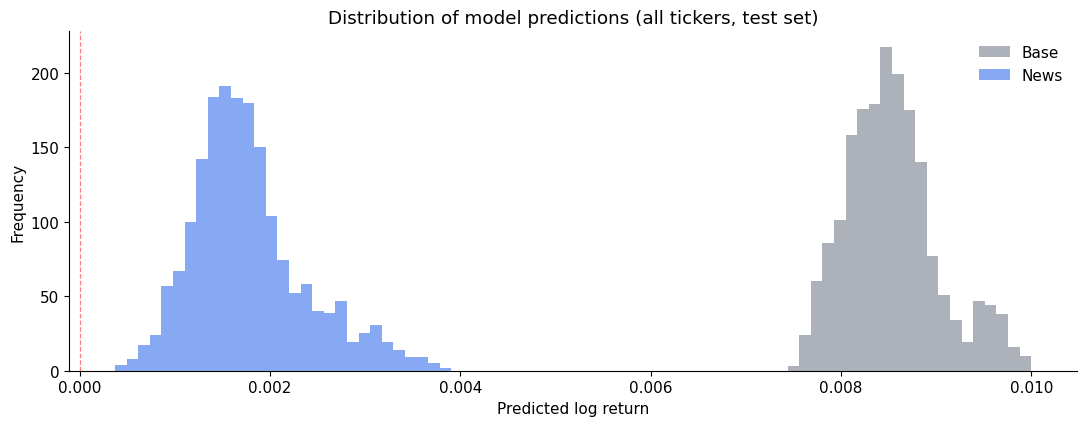

,Stat,Base,News
0,mean,+0.00854,+0.00178
1,std,+0.00049,+0.00060
2,min,+0.00746,+0.00037
3,25%,+0.00820,+0.00138
4,median,+0.00850,+0.00168
5,75%,+0.00879,+0.00204
6,max,+0.01000,+0.00384


In [11]:
preds_base = np.concatenate([base_results[t]["predicted"] for t in common_tickers])
preds_news = np.concatenate([news_results[t]["predicted"] for t in common_tickers])

fig, ax = plt.subplots(figsize=(11, 4.4))
bins = np.linspace(
    min(preds_base.min(), preds_news.min()),
    max(preds_base.max(), preds_news.max()),
    80,
)
ax.hist(preds_base, bins=bins, alpha=0.55, color="#6b7280", label="Base")
ax.hist(preds_news, bins=bins, alpha=0.55, color="#2563eb", label="News")
ax.axvline(0, color="red", linestyle="--", linewidth=0.9, alpha=0.5)
ax.set_xlabel("Predicted log return")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of model predictions (all tickers, test set)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame({
    "Stat":   ["mean", "std", "min", "25%", "median", "75%", "max"],
    "Base":   [preds_base.mean(), preds_base.std(), preds_base.min(),
               np.percentile(preds_base, 25), np.median(preds_base),
               np.percentile(preds_base, 75), preds_base.max()],
    "News":   [preds_news.mean(), preds_news.std(), preds_news.min(),
               np.percentile(preds_news, 25), np.median(preds_news),
               np.percentile(preds_news, 75), preds_news.max()],
})
stats_df.style.format({"Base": "{:+.5f}", "News": "{:+.5f}"})

### 6.5 Scatter — base vs news excess return per ticker

Each point is one ticker. Diagonal line is the "news = base" boundary. Points **above** the line are tickers where news beats base.

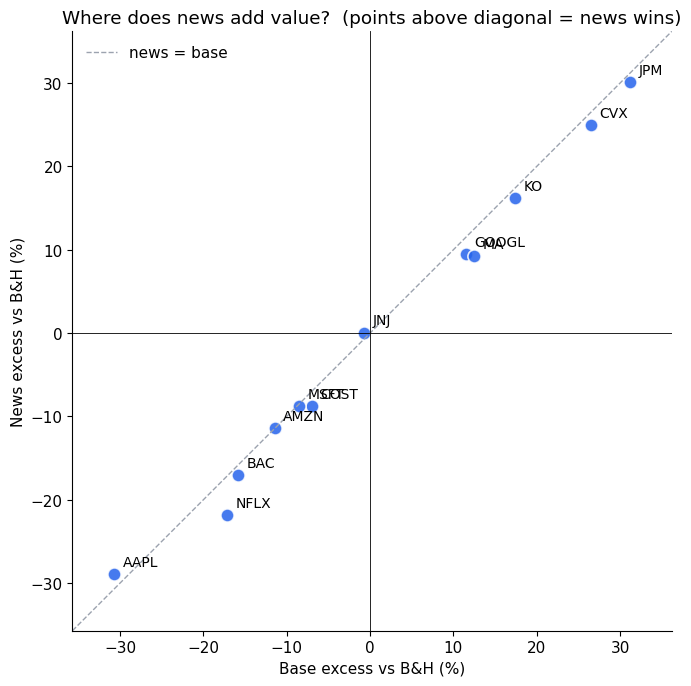

News > Base in 2 tickers,   News < Base in 9,   ties: 1


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 7))
xs = [base_results[t]["metrics"]["excess_vs_bh_pct"] for t in common_tickers]
ys = [news_results[t]["metrics"]["excess_vs_bh_pct"] for t in common_tickers]

ax.scatter(xs, ys, color="#2563eb", s=90, alpha=0.85, edgecolor="white", linewidth=1.2)
for t, x, y in zip(common_tickers, xs, ys):
    ax.annotate(t, (x, y), xytext=(6, 6), textcoords="offset points", fontsize=10)

lo = min(min(xs), min(ys)) - 5
hi = max(max(xs), max(ys)) + 5
ax.plot([lo, hi], [lo, hi], "--", color="#9ca3af", linewidth=1, label="news = base")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel("Base excess vs B&H (%)")
ax.set_ylabel("News excess vs B&H (%)")
ax.set_title("Where does news add value?  (points above diagonal = news wins)")
ax.legend(frameon=False)
ax.set_aspect("equal", "box")
plt.tight_layout()
plt.show()

wins   = sum(1 for x, y in zip(xs, ys) if y > x)
losses = sum(1 for x, y in zip(xs, ys) if y < x)
ties   = len(xs) - wins - losses
print(f"News > Base in {wins} tickers,   News < Base in {losses},   ties: {ties}")